
# Decision Boundary trong Logistic Regression

Notebook này dùng để ghi chú và demo phần **decision boundary** trong Logistic Regression.

Mục tiêu:

- Hiểu decision boundary là gì.
- Biết cách tìm decision boundary từ công thức Logistic Regression.
- Biết cách xác định một điểm thuộc class 0 hay class 1.
- Biết cách vẽ decision boundary bằng Python.



## 1. Logistic Regression nhắc lại

Trong Logistic Regression, model không dự đoán trực tiếp class 0 hoặc 1 ngay từ đầu.

Model sẽ tính một giá trị tuyến tính:

$$
z = w_1x_1 + w_2x_2 + b
$$

Sau đó đưa $z$ qua hàm sigmoid:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Kết quả $\hat{y}$ là xác suất:

$$
\hat{y} = P(y = 1|x)
$$

Nghĩa là model dự đoán xác suất điểm dữ liệu thuộc class 1.



## 2. Quy tắc dự đoán class

Thông thường, ta chọn ngưỡng threshold là:

$$
0.5
$$

Nếu:

$$
\hat{y} \geq 0.5
$$

thì model dự đoán:

$$
y = 1
$$

Nếu:

$$
\hat{y} < 0.5
$$

thì model dự đoán:

$$
y = 0
$$

Vì sigmoid có tính chất:

$$
\sigma(0) = 0.5
$$

nên ranh giới quyết định xảy ra khi:

$$
z = 0
$$



## 3. Decision Boundary là gì?

**Decision boundary** là đường ranh giới mà tại đó model đang phân vân giữa class 0 và class 1.

Tại decision boundary:

$$
\hat{y} = 0.5
$$

Tương đương với:

$$
z = 0
$$

Nếu model có dạng:

$$
z = w_1x_1 + w_2x_2 + b
$$

thì decision boundary là:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Nói đơn giản:

> Decision boundary là đường chia dữ liệu thành hai vùng: một vùng dự đoán class 0, một vùng dự đoán class 1.



## 4. Quy tắc nhớ nhanh

Với:

$$
z = w_1x_1 + w_2x_2 + b
$$

Ta có:

$$
z > 0 \Rightarrow \hat{y} > 0.5 \Rightarrow y = 1
$$

$$
z < 0 \Rightarrow \hat{y} < 0.5 \Rightarrow y = 0
$$

$$
z = 0 \Rightarrow \hat{y} = 0.5
$$

Tại $z = 0$, điểm nằm đúng trên decision boundary.



## 5. Ví dụ tính tay

Giả sử model Logistic Regression học được:

$$
z = 2x_1 + 3x_2 - 6
$$

Decision boundary xảy ra khi:

$$
z = 0
$$

Nên:

$$
2x_1 + 3x_2 - 6 = 0
$$

hay:

$$
2x_1 + 3x_2 = 6
$$

Nếu chuyển về dạng đường thẳng:

$$
3x_2 = 6 - 2x_1
$$

$$
x_2 = 2 - \frac{2}{3}x_1
$$

Vậy decision boundary là đường thẳng:

$$
x_2 = 2 - \frac{2}{3}x_1
$$



## 6. Kiểm tra một điểm thuộc class nào

Vẫn dùng model:

$$
z = 2x_1 + 3x_2 - 6
$$

### Điểm A(1, 1)

$$
z = 2(1) + 3(1) - 6 = -1
$$

Vì:

$$
z < 0
$$

nên:

$$
\hat{y} < 0.5
$$

Model dự đoán:

$$
y = 0
$$

---

### Điểm B(2, 2)

$$
z = 2(2) + 3(2) - 6 = 4
$$

Vì:

$$
z > 0
$$

nên:

$$
\hat{y} > 0.5
$$

Model dự đoán:

$$
y = 1
$$



## 7. Demo Python: tính sigmoid và dự đoán class

Trong demo này, ta dùng model:

$$
z = 2x_1 + 3x_2 - 6
$$

Sau đó viết function để:

1. Tính $z$.
2. Tính sigmoid.
3. Dự đoán class dựa trên threshold 0.5.


In [1]:

import numpy as np

# Hàm sigmoid

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Model: z = 2x1 + 3x2 - 6

def compute_z(x1, x2):
    return 2*x1 + 3*x2 - 6

# Hàm dự đoán class

def predict_class(x1, x2, threshold=0.5):
    z = compute_z(x1, x2)
    y_hat = sigmoid(z)
    predicted_class = 1 if y_hat >= threshold else 0
    return z, y_hat, predicted_class

# Kiểm tra một vài điểm
points = [(1, 1), (2, 2), (3, 0), (0, 2)]

for point in points:
    x1, x2 = point
    z, y_hat, pred = predict_class(x1, x2)
    print(f"Point ({x1}, {x2}) -> z = {z:.2f}, sigmoid(z) = {y_hat:.4f}, predicted class = {pred}")


Point (1, 1) -> z = -1.00, sigmoid(z) = 0.2689, predicted class = 0
Point (2, 2) -> z = 4.00, sigmoid(z) = 0.9820, predicted class = 1
Point (3, 0) -> z = 0.00, sigmoid(z) = 0.5000, predicted class = 1
Point (0, 2) -> z = 0.00, sigmoid(z) = 0.5000, predicted class = 1



## 8. Demo Python: vẽ decision boundary

Với decision boundary:

$$
2x_1 + 3x_2 - 6 = 0
$$

Ta biến đổi thành:

$$
x_2 = 2 - \frac{2}{3}x_1
$$

Ta sẽ vẽ đường này trên mặt phẳng.


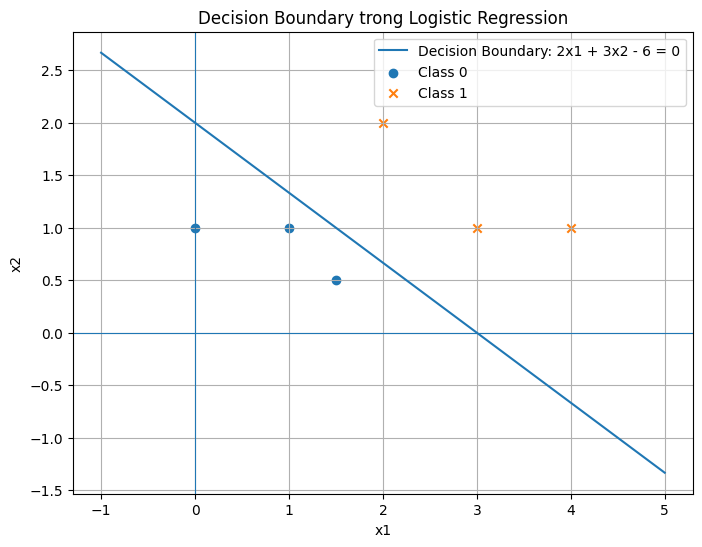

In [2]:

import matplotlib.pyplot as plt

# Tạo dữ liệu x1
x1_values = np.linspace(-1, 5, 100)

# Decision boundary: x2 = 2 - (2/3)x1
x2_boundary = 2 - (2/3)*x1_values

# Một vài điểm demo
points_class_0 = np.array([[1, 1], [0, 1], [1.5, 0.5]])
points_class_1 = np.array([[2, 2], [3, 1], [4, 1]])

plt.figure(figsize=(8, 6))

# Vẽ decision boundary
plt.plot(x1_values, x2_boundary, label="Decision Boundary: 2x1 + 3x2 - 6 = 0")

# Vẽ các điểm class 0 và class 1
plt.scatter(points_class_0[:, 0], points_class_0[:, 1], marker='o', label="Class 0")
plt.scatter(points_class_1[:, 0], points_class_1[:, 1], marker='x', label="Class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary trong Logistic Regression")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True)
plt.legend()
plt.show()



## 9. Demo Python: tô vùng dự đoán class 0 và class 1

Ta sẽ tạo một lưới điểm trên mặt phẳng.

Với mỗi điểm $(x_1, x_2)$, ta tính:

$$
z = 2x_1 + 3x_2 - 6
$$

Nếu:

$$
z \geq 0
$$

thì dự đoán class 1.

Nếu:

$$
z < 0
$$

thì dự đoán class 0.


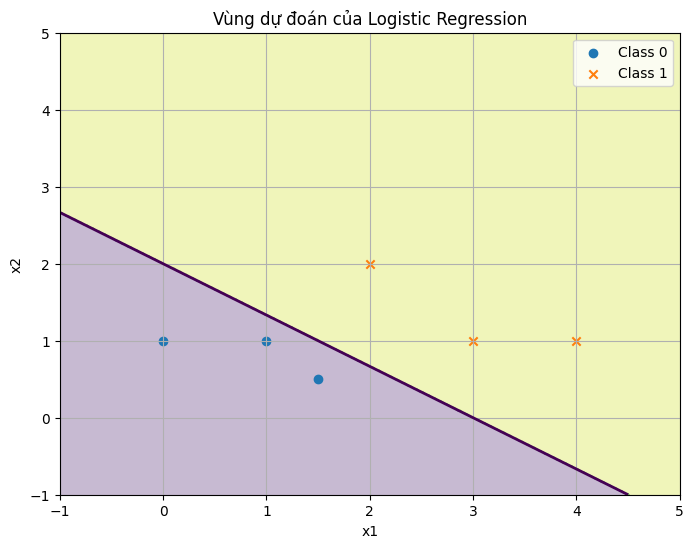

In [3]:

# Tạo lưới điểm
x1_grid = np.linspace(-1, 5, 300)
x2_grid = np.linspace(-1, 5, 300)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Tính z trên toàn bộ lưới
Z = 2*X1 + 3*X2 - 6

# Dự đoán class
Y_pred = (Z >= 0).astype(int)

plt.figure(figsize=(8, 6))

# Tô vùng class 0 và class 1
plt.contourf(X1, X2, Y_pred, alpha=0.3)

# Vẽ decision boundary tại z = 0
plt.contour(X1, X2, Z, levels=[0], linewidths=2)

# Vẽ điểm demo
plt.scatter(points_class_0[:, 0], points_class_0[:, 1], marker='o', label="Class 0")
plt.scatter(points_class_1[:, 0], points_class_1[:, 1], marker='x', label="Class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Vùng dự đoán của Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()



## 10. Bài tập tự luyện

### Bài 1

Cho model:

$$
z = 4x_1 + 2x_2 - 8
$$

Yêu cầu:

1. Tìm decision boundary.
2. Điểm $A(1,1)$ thuộc class nào?
3. Điểm $B(2,1)$ thuộc class nào?

---

### Bài 2

Cho model:

$$
z = -x_1 + 2x_2 - 3
$$

Yêu cầu:

1. Tìm decision boundary.
2. Điểm $A(1,3)$ thuộc class nào?
3. Điểm $B(4,1)$ thuộc class nào?

---

### Bài 3

Cho model:

$$
z = 3x_1 - x_2 + 1
$$

Yêu cầu:

1. Tìm decision boundary.
2. Chuyển decision boundary về dạng $x_2 = ax_1 + b$.
3. Tự chọn 3 điểm và kiểm tra class dự đoán.



## 11. Lời giải bài tập

### Bài 1

Model:

$$
z = 4x_1 + 2x_2 - 8
$$

Decision boundary:

$$
4x_1 + 2x_2 - 8 = 0
$$

$$
4x_1 + 2x_2 = 8
$$

Chia cả hai vế cho 2:

$$
2x_1 + x_2 = 4
$$

Điểm $A(1,1)$:

$$
z = 4(1) + 2(1) - 8 = -2
$$

Vì $z < 0$, nên dự đoán:

$$
y = 0
$$

Điểm $B(2,1)$:

$$
z = 4(2) + 2(1) - 8 = 2
$$

Vì $z > 0$, nên dự đoán:

$$
y = 1
$$



### Bài 2

Model:

$$
z = -x_1 + 2x_2 - 3
$$

Decision boundary:

$$
-x_1 + 2x_2 - 3 = 0
$$

$$
2x_2 = x_1 + 3
$$

$$
x_2 = \frac{1}{2}x_1 + \frac{3}{2}
$$

Điểm $A(1,3)$:

$$
z = -(1) + 2(3) - 3 = 2
$$

Vì $z > 0$, nên dự đoán:

$$
y = 1
$$

Điểm $B(4,1)$:

$$
z = -(4) + 2(1) - 3 = -5
$$

Vì $z < 0$, nên dự đoán:

$$
y = 0
$$



### Bài 3

Model:

$$
z = 3x_1 - x_2 + 1
$$

Decision boundary:

$$
3x_1 - x_2 + 1 = 0
$$

Chuyển về dạng $x_2 = ax_1 + b$:

$$
-x_2 = -3x_1 - 1
$$

$$
x_2 = 3x_1 + 1
$$

Vậy decision boundary là:

$$
x_2 = 3x_1 + 1
$$

Ví dụ kiểm tra điểm $A(0,0)$:

$$
z = 3(0) - 0 + 1 = 1
$$

Vì $z > 0$, nên dự đoán:

$$
y = 1
$$

Ví dụ kiểm tra điểm $B(1,5)$:

$$
z = 3(1) - 5 + 1 = -1
$$

Vì $z < 0$, nên dự đoán:

$$
y = 0
$$



## 12. Tổng kết

Decision boundary không chỉ là lý thuyết. Nó có thể xuất hiện trong bài tập tính toán và bài tập vẽ đồ thị.

Cách làm chuẩn:

1. Viết công thức model:

$$
z = w_1x_1 + w_2x_2 + b
$$

2. Cho $z = 0$ để tìm decision boundary:

$$
w_1x_1 + w_2x_2 + b = 0
$$

3. Kiểm tra điểm bằng cách thay tọa độ vào $z$.

4. Dựa vào dấu của $z$:

$$
z > 0 \Rightarrow y = 1
$$

$$
z < 0 \Rightarrow y = 0
$$

$$
z = 0 \Rightarrow \hat{y} = 0.5
$$

Câu chốt:

> Decision boundary là đường ranh giới mà Logistic Regression dùng để chia dữ liệu thành class 0 và class 1.
